# **Load** **Dataset**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from transformers import BertTokenizer, BertForSequenceClassification, AdamW
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm



In [ ]:
# Dataset is already available locally as dataset.csv
# No need to download from Kaggle


Dataset URL: https://www.kaggle.com/datasets/varshini694/language
License(s): MIT
 54% 3.00M/5.53M [00:00<00:00, 5.44MB/s]
100% 5.53M/5.53M [00:00<00:00, 7.71MB/s]


In [ ]:
# No need to unzip - dataset.csv is already available locally
print('Using local dataset.csv file')


Files unzipped to: /content/language_data


In [ ]:
# Test dataset loading
try:
    data = pd.read_csv('dataset.csv')
    print("✅ Dataset loaded successfully!")
    print(f"Dataset shape: {data.shape}")
    print(f"Columns: {list(data.columns)}")
    print(f"First few rows:")
    print(data.head())
except FileNotFoundError:
    print("❌ Error: dataset.csv file not found in the current directory")
    print("Please make sure dataset.csv is in the same folder as this notebook")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")


# **Dataset** **Visualisation**

In [ ]:
# Load the dataset from local file
data = pd.read_csv('dataset.csv')




In [5]:
# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(data.head())



First few rows of the dataset:
                                                Text  language
0  klement gottwaldi surnukeha palsameeriti ning ...  Estonian
1  sebes joseph pereira thomas  på eng the jesuit...   Swedish
2  ถนนเจริญกรุง อักษรโรมัน thanon charoen krung เ...      Thai
3  விசாகப்பட்டினம் தமிழ்ச்சங்கத்தை இந்துப் பத்திர...     Tamil
4  de spons behoort tot het geslacht haliclona en...     Dutch


In [6]:
# Display the column names
print("\nColumn names:")
print(data.columns)




Column names:
Index(['Text', 'language'], dtype='object')


In [7]:
# Display the number of entries for each language
print("\nNumber of inputs for each language:")
print(data['language'].value_counts())



Number of inputs for each language:
language
Estonian      1000
Swedish       1000
Thai          1000
Tamil         1000
Dutch         1000
Japanese      1000
Turkish       1000
Latin         1000
Urdu          1000
Indonesian    1000
Portugese     1000
French        1000
Chinese       1000
Korean        1000
Hindi         1000
Spanish       1000
Pushto        1000
Persian       1000
Romanian      1000
Russian       1000
English       1000
Arabic        1000
Name: count, dtype: int64


In [8]:

# Check for null values
print("\nNull values in each column:")
print(data.isnull().sum())




Null values in each column:
Text        0
language    0
dtype: int64


In [ ]:
# Display basic statistics
print("\nBasic statistics of the dataset:")
print(data.describe(include='all'))


Basic statistics of the dataset:
                                                     Text  language
count                                               22000     22000
unique                                              21859        22
top     haec commentatio automatice praeparata res ast...  Estonian
freq                                                   48      1000


In [ ]:
# Load the dataset
data = pd.read_csv('dataset.csv')

# Get the number of unique languages
num_languages = data['language'].nunique()

print(f'Number of unique languages in the dataset: {num_languages}')


Number of unique languages in the dataset: 22


<ipython-input-11-75ceab372f73>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='language', order=data['language'].value_counts().index, palette='viridis')


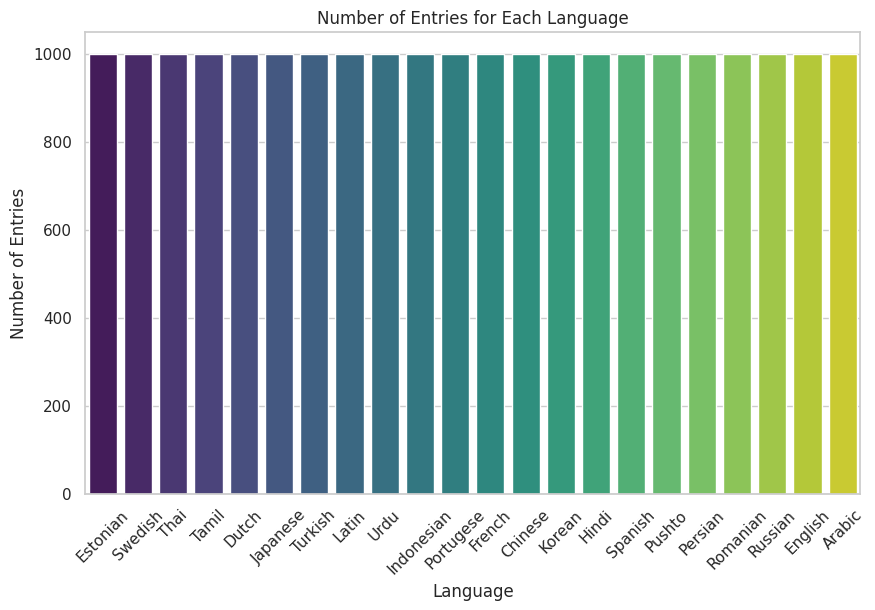

In [ ]:
# Load the dataset
data = pd.read_csv('dataset.csv')

# Set the style for the plots
sns.set(style='whitegrid')

# Visualize the number of entries for each language
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='language', order=data['language'].value_counts().index, palette='viridis')
plt.title('Number of Entries for Each Language')
plt.xlabel('Language')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45)
plt.show()



# **Data** **Preprocessing**

In [ ]:
# All required imports are already loaded in cell 1



In [ ]:
# 1. Text Normalization
# Remove unwanted characters without lowercasing
data['Text'] = data['Text'].apply(lambda x: re.sub(r'[^a-zA-Z0-9\u00C0-\u017F\u0400-\u04FF\u0600-\u06FF\s]', '', x))  # Keep Latin, Cyrillic, Arabic scripts


In [ ]:
# Load the tokenizer first
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Define the chunking function
def chunk_text(text, max_length=512):
    tokens = tokenizer.encode(text, add_special_tokens=True)
    return [tokens[i:i + max_length] for i in range(0, len(tokens), max_length)]

# Apply the chunking function
data['tokens'] = data['Text'].apply(chunk_text)

# If you want to keep the original tokenization (for shorter texts)
# Optionally, you can apply the tokenization only to texts that exceed 512 tokens
data['tokens'] = data['Text'].apply(lambda x: chunk_text(x) if len(tokenizer.encode(x)) > 512 else [tokenizer.encode(x, add_special_tokens=True)])



/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Token indices sequence length is longer than the specified maximum sequence length for this model (718 > 512). Running this sequence through the model will result in indexing errors


In [15]:
# 3. Encoding the Language Labels
label_encoder = LabelEncoder()
data['language_encoded'] = label_encoder.fit_transform(data['language'])



In [16]:
# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(data['tokens'].tolist(), data['language_encoded'], test_size=0.2, random_state=42)

print(f'Train set size: {len(X_train)}, Test set size: {len(X_test)}')


Train set size: 17600, Test set size: 4400


In [17]:
print(type(X_train))  # Should be a list
print(len(X_train))   # Should show the number of training samples
print(X_train[:3])    # Display the first 3 entries to check their structure


<class 'list'>
17600
[[[101, 102]], [[101, 102]], [[101, 1045, 18168, 5856, 16022, 28234, 12789, 2448, 2102, 23624, 3995, 15900, 2319, 2314, 2380, 3914, 12436, 2595, 2121, 1045, 15876, 19722, 5104, 4817, 20857, 21590, 2290, 19817, 4817, 6528, 13749, 2906, 1045, 7939, 19610, 12322, 5686, 7911, 1047, 17960, 20501, 5643, 2078, 29393, 7583, 20042, 6633, 4842, 4017, 5397, 2078, 1045, 19817, 4817, 6528, 12098, 1039, 7939, 13075, 9335, 2618, 24951, 4181, 12098, 21650, 2072, 4830, 19960, 20042, 6633, 4842, 4017, 5397, 2078, 12098, 1039, 28166, 7939, 10556, 25816, 2618, 12098, 5553, 6692, 3089, 19960, 1039, 102]]]


In [18]:
# Display the first 3 entries in X_train
for i, tokens in enumerate(X_train[:3]):
    print(f"Entry {i}: {tokens} (Type: {type(tokens)}, Length: {len(tokens)})")


Entry 0: [[101, 102]] (Type: <class 'list'>, Length: 1)
Entry 1: [[101, 102]] (Type: <class 'list'>, Length: 1)
Entry 2: [[101, 1045, 18168, 5856, 16022, 28234, 12789, 2448, 2102, 23624, 3995, 15900, 2319, 2314, 2380, 3914, 12436, 2595, 2121, 1045, 15876, 19722, 5104, 4817, 20857, 21590, 2290, 19817, 4817, 6528, 13749, 2906, 1045, 7939, 19610, 12322, 5686, 7911, 1047, 17960, 20501, 5643, 2078, 29393, 7583, 20042, 6633, 4842, 4017, 5397, 2078, 1045, 19817, 4817, 6528, 12098, 1039, 7939, 13075, 9335, 2618, 24951, 4181, 12098, 21650, 2072, 4830, 19960, 20042, 6633, 4842, 4017, 5397, 2078, 12098, 1039, 28166, 7939, 10556, 25816, 2618, 12098, 5553, 6692, 3089, 19960, 1039, 102]] (Type: <class 'list'>, Length: 1)


# **Training**

In [19]:
import torch

def prepare_inputs(tokens):
    input_ids = []
    attention_masks = []

    for token_list in tokens:
        # Flatten the token_list from the nested structure
        flat_token_list = token_list[0]  # Extracting the inner list
        # Pad the sequences to a maximum length of 512
        padded = flat_token_list + [0] * (512 - len(flat_token_list))  # Padding with 0s to max length
        attention_mask = [1] * len(flat_token_list) + [0] * (512 - len(flat_token_list))  # Attention mask

        input_ids.append(padded)
        attention_masks.append(attention_mask)

    # Convert lists to tensors
    input_ids_tensor = torch.tensor(input_ids)
    attention_masks_tensor = torch.tensor(attention_masks)

    return input_ids_tensor, attention_masks_tensor


In [ ]:
# Prepare input data
X_train_ids, X_train_masks = prepare_inputs(X_train)
X_test_ids, X_test_masks = prepare_inputs(X_test)

# Convert labels to tensors
y_train_tensor = torch.tensor(y_train.tolist())
y_test_tensor = torch.tensor(y_test.tolist())

# Verify shapes of tensors
print(X_train_ids.shape, X_train_masks.shape, y_train_tensor.shape)
print(X_test_ids.shape, X_test_masks.shape, y_test_tensor.shape)


torch.Size([17600, 512]) torch.Size([17600, 512]) torch.Size([17600])
torch.Size([4400, 512]) torch.Size([4400, 512]) torch.Size([4400])


In [ ]:
# Create TensorDatasets
train_dataset = TensorDataset(X_train_ids, X_train_masks, y_train_tensor)
test_dataset = TensorDataset(X_test_ids, X_test_masks, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)


In [ ]:
# Load the BERT model for sequence classification
model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=22)  # Set num_labels to the number of languages


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Set up the optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)  # You can adjust the learning rate as needed


/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
# Move the model to the GPU if available
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

# Training loop
epochs = 5
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in tqdm(train_loader):
        input_ids, attention_masks, labels = [b.to(device) for b in batch]

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids, attention_mask=attention_masks, labels=labels)
        loss = outputs.loss

        # Backward pass
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch {epoch + 1}, Average Loss: {avg_loss}')


100%|██████████| 1100/1100 [25:09<00:00,  1.37s/it]


Epoch 1, Average Loss: 0.8265978335385973


100%|██████████| 1100/1100 [25:14<00:00,  1.38s/it]


Epoch 2, Average Loss: 0.5249304409189658


100%|██████████| 1100/1100 [25:14<00:00,  1.38s/it]


Epoch 3, Average Loss: 0.4664825173708695


100%|██████████| 1100/1100 [25:17<00:00,  1.38s/it]


Epoch 4, Average Loss: 0.4120220931191844


100%|██████████| 1100/1100 [25:17<00:00,  1.38s/it]

Epoch 5, Average Loss: 0.3768479640032588


In [ ]:
# Set the model to evaluation mode
model.eval()
predictions = []
true_labels = []

# Disable gradient calculation for evaluation
with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_masks, labels = [b.to(device) for b in batch]

        # Get model predictions
        outputs = model(input_ids, attention_mask=attention_masks)

        # Get the predicted class (index of the max logit)
        _, preds = torch.max(outputs.logits, dim=1)

        # Append predictions and true labels
        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

# Calculate accuracy
accuracy = accuracy_score(true_labels, predictions)

# Generate a classification report
report = classification_report(true_labels, predictions, target_names=label_encoder.classes_)

# Print the results
print(f'Accuracy: {accuracy:.4f}')
print('Classification Report:')
print(report)


Accuracy: 0.7993
Classification Report:
              precision    recall  f1-score   support

      Arabic       1.00      1.00      1.00       202
     Chinese       0.43      0.20      0.28       201
       Dutch       1.00      0.99      0.99       230
     English       0.98      0.98      0.98       194
    Estonian       1.00      0.96      0.98       200
      French       0.97      0.99      0.98       188
       Hindi       0.65      0.10      0.17       208
  Indonesian       1.00      1.00      1.00       213
    Japanese       0.55      0.26      0.36       194
      Korean       0.53      0.11      0.18       190
       Latin       0.95      0.97      0.96       210
     Persian       0.99      0.99      0.99       196
   Portugese       0.97      0.99      0.98       194
      Pushto       0.99      0.98      0.98       196
    Romanian       0.98      0.97      0.98       197
     Russian       0.98      1.00      0.99       213
     Spanish       0.97      0.99      0.

In [ ]:
torch.save(model.state_dict(), 'modelname.pth')

In [ ]:
# Install required packages (run this in terminal if needed)
# pip install pytesseract pillow torch transformers scikit-learn


In [ ]:
import pytesseract
from PIL import Image
import torch
import re
# Note: For local environment, you may need to install tesseract separately
# For Windows: Download from https://github.com/UB-Mannheim/tesseract/wiki
# For Linux: sudo apt-get install tesseract-ocr
# For macOS: brew install tesseract



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 1s (4,820 kB/s)
Selecting previously unselected package tesseract-ocr-eng.
(Reading database ... 123622 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-

In [35]:
# Function to extract text from an image
def extract_text_from_image(image_path):
    image = Image.open(image_path)
    text = pytesseract.image_to_string(image)
    return text


In [ ]:
# Function to predict language
def predict_language(text, model, tokenizer, device):
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    tokens = tokenizer.encode(text, add_special_tokens=True)
    tokens = tokens[:512]
    padded = tokens + [0] * (512 - len(tokens))
    attention_mask = [1] * len(tokens) + [0] * (512 - len(tokens))

    input_ids_tensor = torch.tensor([padded]).to(device)
    attention_mask_tensor = torch.tensor([attention_mask]).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_ids_tensor, attention_mask=attention_mask_tensor)
        _, preds = torch.max(outputs.logits, dim=1)

    return label_encoder.inverse_transform(preds.cpu().numpy())


In [ ]:
# Main function to run the pipeline
def main(image_path):
    extracted_text = extract_text_from_image(image_path)
    print(f'Extracted Text: {extracted_text}')
    predicted_language = predict_language(extracted_text, model, tokenizer, device)
    print(f'Predicted Language: {predicted_language[0]}')

# Example usage with a local image file
# Replace 'your_image.jpg' with the actual path to your image
image_path = 'your_image.jpg'  # Update this path to your actual image file

# Uncomment the line below to run the prediction
# main(image_path)

Saving WhatsApp Image 2024-10-27 at 22.55.46.jpeg to WhatsApp Image 2024-10-27 at 22.55.46 (1).jpeg
Using image: WhatsApp Image 2024-10-27 at 22.55.46 (1).jpeg
Extracted Text:  

Predicted Language: Tamil
